## HW3 Jenn Kaphammer

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import solve_ivp

## Q1

In [10]:
#Based on spike_map.py from Canvas, with modifications made for sin based model
#----------------
TWOPI = 2 * np.pi

def forced_lif(I=1.6, eps=0.5, T=200.0, dt=1e-4):
    nt = int(round(T / dt)) + 1
    t = np.linspace(0, T, nt)

    v = 0.0
    spikes = []

    for j in range(nt - 1):
        v += dt * (I_t(t[j], I, eps) - v)

        if v >= 1:
            spikes.append(t[j + 1])
            v = 0.0

    spikes = np.array(spikes)
    return spikes

#uses threshold crossings
def next_spike(Tn, I, eps=0.5, step=0.01, max_wait=10):
    def threshold(t):
        v = G(t, I, eps) - G(Tn, I, eps) * np.exp(-(t - Tn))
        return v - 1

    # search forward until first crossing
    a = Tn
    fa = threshold(a)

    t = Tn + step
    while t <= Tn + max_wait:
        ft = threshold(t)

        if fa < 0 and ft >= 0:
            return brentq(threshold, t - step, t)

        fa = ft
        t += step

    return None
def forced_lif_fast(I, eps=0.5, T=300):
    spikes = []
    Tn = 0.0

    while Tn < T:
        Tnext = next_spike(Tn, I, eps)

        if Tnext is None or Tnext > T:
            break

        spikes.append(Tnext)
        Tn = Tnext

    return np.array(spikes)

def I_t(t, I=1.6, eps=0.5):
    return I + eps * np.sin(TWOPI * t)

def G(t, I=1.6, eps=0.5):
    return (
        I
        + eps / (1 + 4 * np.pi**2)
        * (np.sin(TWOPI * t) - TWOPI * np.cos(TWOPI * t))
    )

I_star = 1 / (1 - np.exp(-1))

def locking_condition(phi, I=1.6, eps=0.5):
    return G(phi, I, eps) - I_star

def locking_phases(I=1.6, eps=0.5, n=4001):
    xs = np.linspace(0, 1, n)
    vals = locking_condition(xs, I, eps)

    roots = []

    for i in range(n - 1):
        if vals[i] * vals[i + 1] < 0:
            root = brentq(
                locking_condition,
                xs[i],
                xs[i + 1],
                args=(I, eps)
            )
            roots.append(root)

    return roots


### 1b- candidate locked states

In [4]:
roots = locking_phases(I=1.6, eps=0.5)
print(roots)

[0.18805233981971606, 0.7617084319634079]


In [5]:
#lambda multiplier
def multiplier(phi, I=1.6, eps=0.5):
    Iphi = I_t(phi, I, eps)
    return np.exp(-1) * Iphi / (Iphi - 1)

for phi in roots:
    Iphi = I_t(phi, 1.6, 0.5)
    lam = multiplier(phi, 1.6, 0.5)

    print(
        f"phi = {phi:.4f}, "
        f"I(phi) = {Iphi:.4f}, "
        f"lambda = {lam:.4f}"
    )

phi = 0.1881, I(phi) = 2.0626, lambda = 0.7141
phi = 0.7617, I(phi) = 1.1014, lambda = 3.9976


### 1c - sim

In [23]:
eps = 0.5

#300 time units
I_values = np.linspace(0.9, 3.0, 300)
T_total = 150
T_transient = 50

firing_numbers = []

for I in I_values:
    spikes = forced_lif_fast(I, eps=eps, T=T_total)

    spikes_ss = spikes[spikes >= T_transient]

    firing_number = len(spikes_ss) / (T_total - T_transient)

    firing_numbers.append(firing_number)

firing_numbers = np.array(firing_numbers)

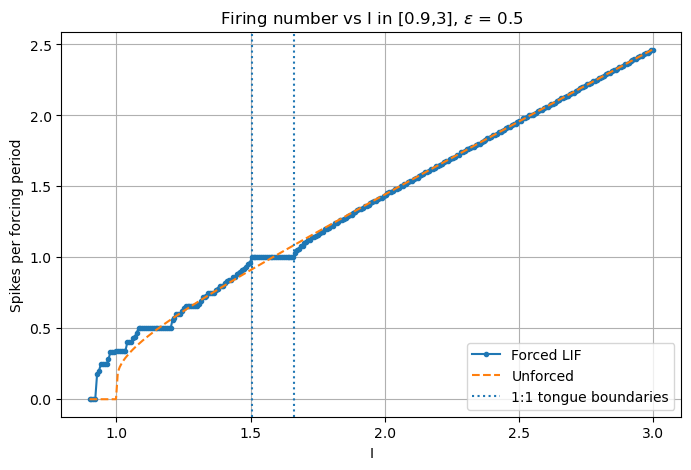

In [30]:
# unforced firing number
unforced = np.zeros_like(I_values)

mask = I_values > 1
unforced[mask] = 1 / np.log(I_values[mask] / (I_values[mask] - 1))

# 1:1 tongue boundaries
I_star = 1 / (1 - np.exp(-1))

I_lower = I_star - eps / np.sqrt(1 + 4*np.pi**2)
I_upper = I_star + eps / np.sqrt(1 + 4*np.pi**2)

plt.figure(figsize=(8, 5))

plt.plot(
    I_values,
    firing_numbers,
    marker="o",
    markersize=3,
    label="Forced LIF"
)

plt.plot(
    I_values,
    unforced,
    linestyle="--",
    label="Unforced"
)

plt.axvline(
    I_lower,
    linestyle=":",
    label="1:1 tongue boundaries"
)

plt.axvline(
    I_upper,
    linestyle=":"
)

plt.xlabel("I")
plt.ylabel("Spikes per forcing period")
plt.title("Firing number vs I in [0.9,3], $\epsilon$ = 0.5")

plt.legend()
plt.grid(True)
plt.show()

In [33]:
#eyeball of other plateaus
targets = [1/4, 1/3, 1/2, 2/3]
for target in targets:
    inds = np.where(np.isclose(firing_numbers, target, atol=0.015))[0]

    if len(inds) > 0:
        print(
            target,
            I_values[inds[0]],
            I_values[inds[-1]]
        )

0.25 0.9421404682274248 0.9632107023411371
0.3333333333333333 0.9772575250836121 1.0334448160535117
0.5 1.0826086956521739 1.2020066889632108
0.6666666666666666 1.2581939799331103 1.3073578595317725


The measured 1:1 plateau in the simulation is between approximately the same two boundaries, so the numerical result agrees with the prediction.
Four other visible plateaus are at approximately the firing numbers 0.25, 0.33, 0.5, 0.67.

In [25]:
#phase of spikes at 1.6
spikes = forced_lif_fast(I=1.6, eps=0.5, T=100)

# discard transient spikes
spikes_ss = spikes[spikes >= 50]

# convert spike times to forcing phases
phases = spikes_ss % 1
p_mean = np.mean(phases[-10:])
print("last 10 phases:")
print(phases[-10:])

print("mean phase:")
print(p_mean)

last 10 phases:
[0.18805234 0.18805234 0.18805234 0.18805234 0.18805234 0.18805234
 0.18805234 0.18805234 0.18805234 0.18805234]
mean phase:
0.18805233981950664


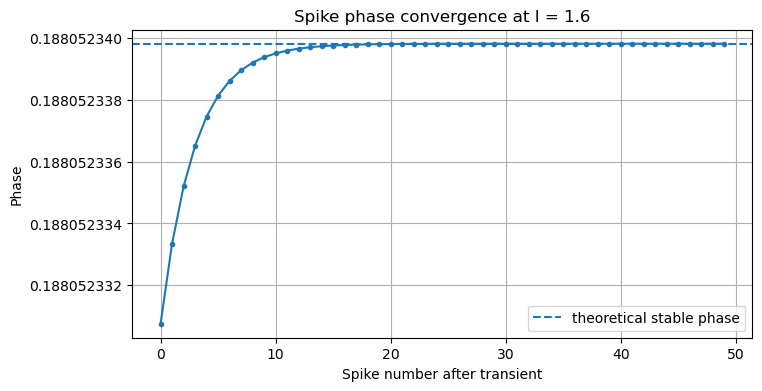

In [20]:
plt.figure(figsize=(8, 4))

plt.plot(phases, marker="o", markersize=3)

ax = plt.gca()
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
plt.axhline(
    p_mean,
    linestyle="--",
    label="theoretical stable phase"
)

plt.xlabel("Spike number after transient")
plt.ylabel("Phase")
plt.title("Spike phase convergence at I = 1.6")

plt.legend()
plt.grid(True)

plt.show()

At $(I=1.6)$ and $\epsilon=0.5$, the simulated spike phases converge to $\phi\approx0.1881\$. This agrees with the stable 1:1 locked phase in part b.

## Q2

### 2c - PRC by direct perturbation

#### LIF

In [34]:
#Based on prc.py from Canvas, with modifications made for LIF
#----------------
tau = 1.0
vr = 0.0
vth = 1.0
I = 1.5
delta = 1e-3

def lif_period(I=1.5, tau=1.0, vr=0.0, vth=1.0):
    return tau * np.log((I*tau - vr) / (I*tau - vth))


def lif_exact_prc(phi, I=1.5, tau=1.0, vr=0.0):
    Delta = lif_period(I, tau, vr, vth)

    return (
        tau * np.exp(phi * Delta / tau)
        / (Delta * (I*tau - vr))
    )
def lif_prc_numeric(
    I=1.5,
    tau=1.0,
    vr=0.0,
    vth=1.0,
    delta=1e-3,
    nphase=100
):
    Delta = lif_period(I, tau, vr, vth)

    #endpoint = false excludes exactly phi=1 since that's exactly reset
    phases = np.linspace(0, 1, nphase, endpoint=False)
    R_num = np.zeros(nphase)

    for i, phi in enumerate(phases):

        # voltage on the unperturbed orbit at phase phi
        t_kick = phi * Delta

        v_phi = (
            I*tau
            + (vr - I*tau) * np.exp(-t_kick / tau)
        )

        # apply voltage kick
        v_kicked = v_phi + delta

        # time remaining after kick until threshold
        remaining = tau * np.log(
            (I*tau - v_kicked)
            / (I*tau - vth)
        )

        # next spike time measured from reset
        T0 = t_kick + remaining

        # numerical PRC
        R_num[i] = (Delta - T0) / (Delta * delta)

    return phases, R_num, Delta

In [35]:
phases, R_num, Delta = lif_prc_numeric()

R_exact = lif_exact_prc(phases)

print("period =", Delta)

period = 1.0986122886681098


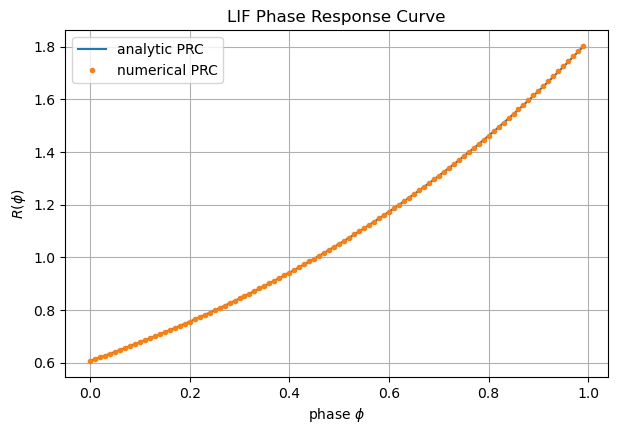

In [44]:
plt.figure(figsize=(7, 4.5))

plt.plot(
    phases,
    R_exact,
    label="analytic PRC"
)

plt.plot(
    phases,
    R_num,
    ".",
    label="numerical PRC"
)

plt.xlabel(r"phase $\phi$")
plt.ylabel(r"$R(\phi)$")
plt.title("LIF Phase Response Curve")

plt.legend()
plt.grid(True)

plt.show()

The measured period $\delta$ = $ln(3) \approx 1.099$. The numerically measured PRC agrees closely with the analytic expression $
R(\phi)=\frac{e^{\phi\Delta}}{1.5\Delta}$. This is a Type I PRC as it is positive for all phases.

#### FitzHugh-Nagumo PRC

In [45]:
#Based on prc.py and fn_sim.py from Canvas
#----------------
def fhn_rhs(t, y):
    v, w = y

    dv = v - v**3 / 3 - w + 0.5
    dw = 0.08 * (v + 0.7 - 0.8*w)

    return [dv, dw]
    
def fhn_sim(y0=(-1.0, 1.0), T=500, dt=0.01):
    t_eval = np.arange(0, T + dt, dt)

    sol = solve_ivp(
        fhn_rhs,
        [0, T],
        y0,
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-11
    )

    return sol.t, sol.y[0], sol.y[1]

#find upwards v=0 crossings for phase 0
def upward_crossings(t, v):
    crossing_times = []

    for i in range(len(v) - 1):
        if v[i] < 0 and v[i + 1] >= 0:
            # linear interpolation for a more accurate crossing time
            frac = -v[i] / (v[i + 1] - v[i])

            tcross = t[i] + frac * (t[i + 1] - t[i])

            crossing_times.append(tcross)

    return np.array(crossing_times)

In [46]:
t, v, w = fhn_sim()

crossings = upward_crossings(t, v)

print(crossings[-10:])

[140.68856977 180.16298083 219.63739659 259.11181352 298.58622463
 338.06064745 377.53505392 417.00947792 456.48388443 495.95830378]


In [47]:
periods = np.diff(crossings[-10:])

Delta = np.mean(periods)

print("period =", Delta)

period = 39.47441488997415


In [48]:
#unperturbed period approx 39.47
#kick v and measure shift
t0 = crossings[-5]
idx0 = np.argmin(np.abs(t - t0))

v0 = v[idx0]
w0 = w[idx0]

print(v0, w0)

-0.000426805314962312 -0.15667990443252072


In [58]:
def fhn_prc_at_phase(phi, Delta, w0, delta=1e-3, n_relax=3, dt=0.01):

    y_start = [0.0, w0]

    t_kick = phi * Delta

    # evolve from phase 0 to the kick phase
    if phi == 0:
        v_kick, w_kick = y_start

    else:
        sol1 = solve_ivp(
            fhn_rhs,
            [0, t_kick],
            y_start,
            t_eval=[t_kick],
            rtol=1e-9,
            atol=1e-11
        )

        v_kick, w_kick = sol1.y[:, -1]

    # apply small voltage kick
    v_kick += delta

    # simulate for a few cycles after the kick
    T_after = (n_relax + 1) * Delta

    npts = int(T_after / dt) + 1
    t_eval = np.linspace(0, T_after, npts)

    sol2 = solve_ivp(
        fhn_rhs,
        [0, T_after],
        [v_kick, w_kick],
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-11
    )

    # find upward v = 0 crossings
    pert_crossings = upward_crossings(
        sol2.t,
        sol2.y[0]
    )

    # choose a crossing after several cycles of relaxation
    k = n_relax - 1

    T_pert = t_kick + pert_crossings[k]

    # unperturbed time of the corresponding crossing
    T_ref = (k + 1) * Delta

    # PRC estimate
    R = (T_ref - T_pert) / (Delta * delta)

    return R

In [59]:
phases = np.linspace(0, 1, 50, endpoint=False)

R_num = np.array([
    fhn_prc_at_phase(phi, Delta, w0)
    for phi in phases
])

In [60]:
print("phases:", phases)
print("R_num:", R_num)

print("len phases =", len(phases))
print("len R_num =", len(R_num))

phases: [0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26
 0.28 0.3  0.32 0.34 0.36 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54
 0.56 0.58 0.6  0.62 0.64 0.66 0.68 0.7  0.72 0.74 0.76 0.78 0.8  0.82
 0.84 0.86 0.88 0.9  0.92 0.94 0.96 0.98]
R_num: [ 0.02592821  0.00662957  0.00121837  0.00080014  0.00146416  0.00256583
  0.00414017  0.00614545  0.00833418  0.00957989  0.00710667 -0.00360328
 -0.02675564 -0.06164196 -0.09850247 -0.12047597 -0.11457312 -0.0832561
 -0.044367   -0.01789349 -0.0089103  -0.00794167 -0.00843256 -0.00907938
 -0.00987829 -0.0108688  -0.01210289 -0.01365813 -0.01565078 -0.01826122
 -0.02177127 -0.02660456 -0.0333283  -0.04252953 -0.05443856 -0.06822127
 -0.08096133 -0.08732707 -0.08005186 -0.05186768  0.00083791  0.07450579
  0.15643595  0.22840574  0.27266009  0.27869555  0.24726893  0.1897678
  0.1234607   0.06543326]
len phases = 50
len R_num = 50


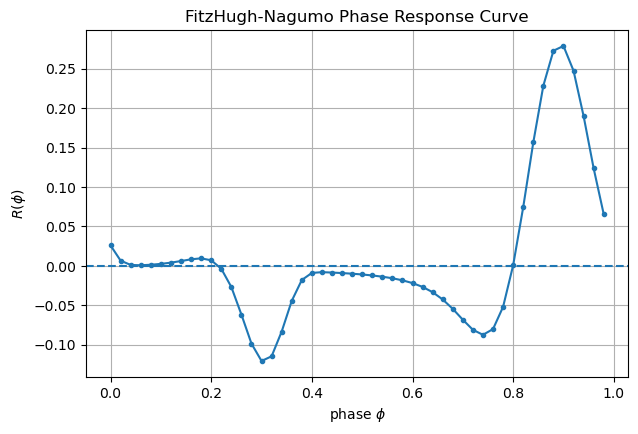

In [61]:
plt.figure(figsize=(7, 4.5))

plt.plot(phases, R_num, marker="o", markersize=3)

plt.axhline(0, linestyle="--")

plt.xlabel(r"phase $\phi$")
plt.ylabel(r"$R(\phi)$")
plt.title("FitzHugh-Nagumo Phase Response Curve")

plt.grid(True)
plt.show()

In [62]:
R_min = np.min(R_num)
R_max = np.max(R_num)

phi_min = phases[np.argmin(R_num)]
phi_max = phases[np.argmax(R_num)]

negative_phases = phases[R_num < 0]

print("R_min =", R_min, "at phi =", phi_min)
print("R_max =", R_max, "at phi =", phi_max)

print("negative phase range:")
print(negative_phases[0], "to", negative_phases[-1])

R_min = -0.12047596559317504 at phi = 0.3
R_max = 0.27869554719578443 at phi = 0.9
negative phase range:
0.22 to 0.78


This FitzHugh-Nagumo PRC has fluxates to both positive and negative over phaes, so it's Type II. \
The minimum is about -0.12, and the maximum is about 0.27. \
The period is about 39.47. 
The model is $R(\phi)<0$ over approximately $\phi \in (0.21, 0.8)$.
Physically, the negative PRC values means that the pertubation delays the oscillator's phase. Specifically, a small positive voltage 'kick' during these phases cause the spike to occur later.

## Q4

### 4c - gap-junction QIF

In [1]:
#Based on kuramoto.py from Canvas, modified to match hw lag definition 
#----------------
def qif_gap_pair(eps=0.02, L=200.0, phi0=0.4,
                 T=300.0, dt=1e-4):

    nt = int(round(T / dt)) + 1
    t = np.linspace(0, T, nt)

    v1 = np.zeros(nt)
    v2 = np.zeros(nt)

    # Neuron 1 has just spiked at t = 0 and is reset.
    v1[0] = -L

    # Neuron 2 is phi0 cycles behind neuron 1 in spike timing,
    # so it has phi0 of a cycle left before its next spike.
    theta2_0 = 1.0 - phi0
    v2[0] = -1.0 / np.tan(np.pi * theta2_0)

    # Count t = 0 as neuron 1's initial spike.
    spikes1 = [0.0]
    spikes2 = []

    for j in range(nt - 1):

        dv1 = 1 + v1[j]**2 + eps * (v2[j] - v1[j])
        dv2 = 1 + v2[j]**2 + eps * (v1[j] - v2[j])

        v1[j + 1] = v1[j] + dt * dv1
        v2[j + 1] = v2[j] + dt * dv2

        if v1[j + 1] >= L:
            spikes1.append(t[j + 1])
            v1[j + 1] = -L

        if v2[j + 1] >= L:
            spikes2.append(t[j + 1])
            v2[j + 1] = -L

    return (
        t,
        v1,
        v2,
        np.array(spikes1),
        np.array(spikes2)
    )

def measure_lag(spikes1, spikes2):
    n = min(len(spikes1) - 1, len(spikes2))

    phi_k = []
    t_k = []

    for k in range(n):
        period1 = spikes1[k + 1] - spikes1[k]
        lag = spikes2[k] - spikes1[k]

        phi_k.append(lag / period1)
        t_k.append(spikes1[k])

    return np.array(t_k), np.array(phi_k)

In [4]:
t, v1, v2, spikes1, spikes2 = qif_gap_pair(
    eps=0.02,
    L=200.0,
    phi0=0.4,
    T=300.0,
    dt=1e-4
)

tk, phi_k = measure_lag(spikes1, spikes2)

In [5]:
#check values
print("first measured phi =", phi_k[0])
print("target phi0 =", 0.4)
print("difference =", phi_k[0] - 0.4)

first measured phi = 0.42764434547478924
target phi0 = 0.4
difference = 0.027644345474789223


In [6]:
phi_theory = (
    np.arctan(
        np.tan(np.pi * 0.4)
        * np.exp(-2 * 0.02 * tk)
    )
    / np.pi
)

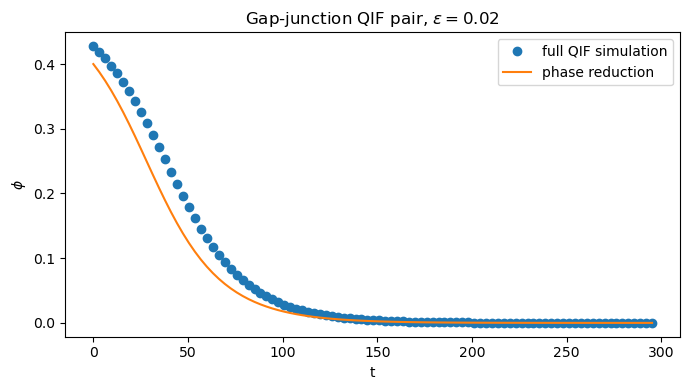

In [7]:
plt.figure(figsize=(7, 4))

plt.plot(tk, phi_k, "o", label="full QIF simulation")
plt.plot(tk, phi_theory, "-", label="phase reduction")

plt.xlabel("t")
plt.ylabel(r"$\phi$")
plt.title(r"Gap-junction QIF pair, $\epsilon=0.02$")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
#check numbers to theory
y = np.log(np.tan(np.pi * phi_k))

mask = (phi_k > 0) & (phi_k < 0.49)

slope, intercept = np.polyfit(tk[mask], y[mask], 1)

print("fitted slope =", slope)
print("fitted decay rate =", -slope)
print("predicted decay rate =", 2 * 0.02)

fitted slope = -0.039417524111982176
fitted decay rate = 0.039417524111982176
predicted decay rate = 0.04


For coupling strength $\epsilon=0.02$, the fitted decay rate was approximately 0.039. This agrees with the phase-reduction prediction $2\epsilon=0.04$.

In [10]:
#decay rate fit for given values
eps_values = [0.005, 0.02, 0.05]

for eps in eps_values:

    t, v1, v2, spikes1, spikes2 = qif_gap_pair(
        eps=eps,
        L=200.0,
        phi0=0.4,
        T=300.0,
        dt=1e-4
    )

    tk, phi_k = measure_lag(spikes1, spikes2)

    mask = (phi_k > 0) & (phi_k < 0.49)

    y = np.log(np.tan(np.pi * phi_k[mask]))
    x = tk[mask]

    slope, intercept = np.polyfit(x, y, 1)

    fitted_rate = -slope
    predicted_rate = 2 * eps

    print(f"eps = {eps}")
    print(f"fitted rate    = {fitted_rate:.6f}")
    print(f"predicted rate = {predicted_rate:.6f}")
    print()

eps = 0.005
fitted rate    = 0.009687
predicted rate = 0.010000

eps = 0.02
fitted rate    = 0.039418
predicted rate = 0.040000

eps = 0.05
fitted rate    = 0.096829
predicted rate = 0.100000



The fitted rates match closely to the theoretical values for $2\epsilon =0.01, 0.04, 0.10$. \


The $\pm L$ cutoff is important as ideally, a QIF voltage as a singularity at the spike. The threshold and reset help preserve this cancellation as best as possible for a finite simulation.